In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'object_detection'
os.environ['KAGGLE_KEY'] = 'KAGAT_3551c25805b2eade6f2dc0bcfac013fb'

print("Đã thiết lập xác thực Kaggle thành công!")

Đã thiết lập xác thực Kaggle thành công!


In [ ]:
!kaggle datasets download -d sukmaadhiwijaya/welding-defect-object-detection

!unzip -q welding-defect-object-detection.zip -d welding_data

Dataset URL: https://www.kaggle.com/datasets/sukmaadhiwijaya/welding-defect-object-detection
License(s): CC0-1.0
 89% 135M/152M [00:00<00:00, 1.41GB/s]
100% 152M/152M [00:00<00:00, 1.39GB/s]


In [ ]:
import yaml

data_config = {
    'train': '/content/welding_data/train/images',
    'val': '/content/welding_data/valid/images',
    'nc': 3,  # Số lượng lớp (bad weld, good weld, defect)
    'names': ['bad weld', 'defect', 'good weld']
}

with open('/content/welding_data/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Đã tạo file data.yaml thành công!")

Đã tạo file data.yaml thành công!


In [ ]:

from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/data.yaml',
    epochs=50,
    imgsz=640,
    device=0,
    project='welding_project',
    name='weld_detection'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weld_detection, nbs=64, nms=False, opset=None, optimize=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c49209e6f60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/176 /content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/valid/images/886d6ca3-1b242175-download_1_jpeg_jpg.rf.386935bff2eb78c24af0001e8b15401f.jpg: 640x640 2 Good Welds, 8.6ms
image 2/176 /content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/valid/images/Good-Welding-images_22_jpeg_jpg.rf.318c9d57367dca722350fe8d63b44591.jpg: 640x640 (no detections), 7.2ms
image 3/176 /content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/valid/images/Not-perfect-welding-images_10_jpeg_jpg.rf.938705132c676bde86605b449fbfd55e.jpg: 640x640 2 Good Welds, 7.2ms
image 4/176 /content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/valid/images/Not-perfect-welding-images_17_jpeg_jpg.rf.64e46e84fb95dfb5e6eecc845629350c.jpg: 640x640 (no detections), 7.2ms
image 5/176 /content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/valid/images/SampleV1_1_mp4-14_jpg.rf.a63c344a8a0ff6183f314d4a5b231a71.jpg: 6

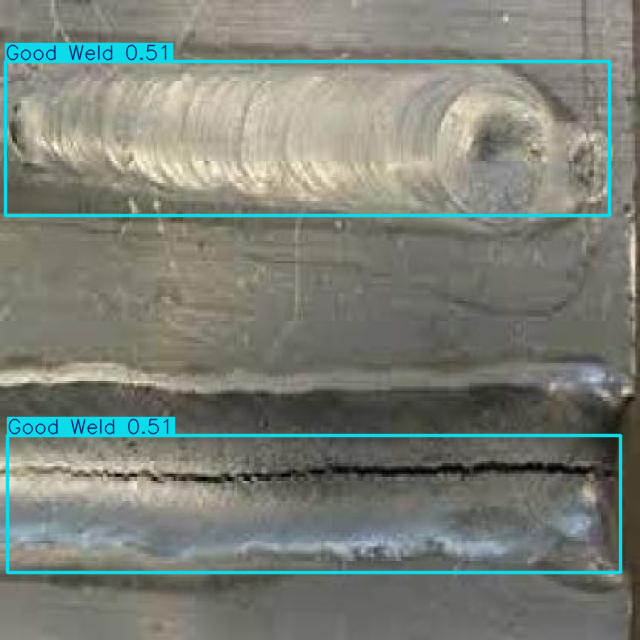

Kết quả ảnh thứ 2:


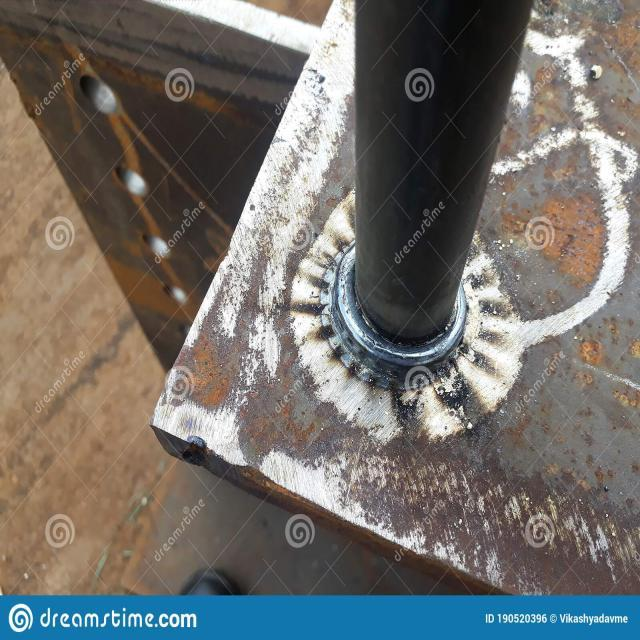

Kết quả ảnh thứ 3:


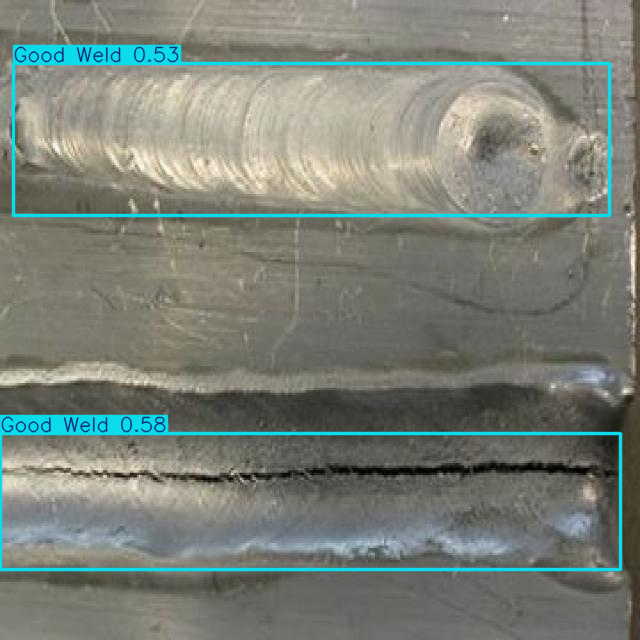

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO('/content/runs/detect/welding_project/weld_detection/weights/best.pt')

results = model.predict(source='/content/welding_data/The Welding Defect Dataset/The Welding Defect Dataset/valid/images', conf=0.5, save=True)

# 3. Hiển thị thử 2-3 tấm ảnh đầu tiên ngay trên Colab
for i in range(3):
    annotated_frame = results[i].plot()
    print(f"Kết quả ảnh thứ {i+1}:")
    cv2_imshow(annotated_frame)

In [ ]:
video_path = '/content/1723687d-6dd44d6e-Centerline-Crack_jpg.rf.7319890841c35639f6cd82c78a1203a4.jpg'

results = model.predict(source=video_path, save=True, conf=0.4)

print("--- HOÀN THÀNH ---")
print("Video đã có khung khoanh vùng nằm tại: runs/detect/predict/")

NameError: name 'model' is not defined

In [ ]:
!apt-get install unrar
# Giải nén file vào thư mục 'data_weld'
!unrar x "/content/bad welding.rar" "/content/data_weld/"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/bad welding.rar

Creating    /content/data_weld                                        OK
Creating    /content/data_weld/bad welding                            OK
Extracting  /content/data_weld/bad welding/15aa20b4-71f6-4dd0-8f6e-0ab9fcf5c584.jpg       0%  OK 
Extracting  /content/data_weld/bad welding/39dbf56b-b54f-4d9a-bbbd-9df66dd945f9.jpg       1%  OK 
Extracting  /content/data_weld/bad welding/41be4c70-a1c0-4ca9-a8fd-88dea50644c5.jpg       2%  OK 
Extracting  /content/data_weld/bad welding/4519650.webp                    5%  OK 
Extracting  /content/data_weld/bad welding/4e5c91cb-9eee-468c-b575-7180358b59a7.jpg       6%  O

In [1]:
!pip install ultralytics
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
print("Thành công!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Thành công!
